In [1]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector
import matplotlib.pyplot as plt
fig_dir, data_dir = './figs', './data'

In [112]:
scale = 1
n = 8 # 10
t = 3 / scale
r = 50 # 100

dt = t/r
H_model = 'MFI'
hx, hy, Jx = 1*scale, 0.9*scale, 0.8*scale
# n = 21
qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
xx_even = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[::2]], num_qubits=n).simplify()
xx_odd = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[1::2]], num_qubits=n).simplify()
x_terms = SparsePauliOp.from_sparse_list([*qimf.x_tuples], num_qubits=n).simplify()
H_list = [x_terms, qimf.y_terms, xx_even, xx_odd] # [xx_even, x_terms, qimf.y_terms,xx_odd]
H_ordered = sum(H_list)
dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_ordered), dt, use_jax=False)
U_dt_appro = pf(H_ordered, dt, 1, 1)
# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
complete_fnorm = 2**(-n/2)*np.linalg.norm(z1.to_matrix(), ord='fro')

t_num_dense = 50
U_dt_ideal_dense = expH(sum(H_ordered), t/t_num_dense, use_jax=False)
ideal_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_ideal_dense, i)@init_state) for i in range(t_num_dense+1)]
trott_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_appro, i)@init_state) for i in range(r+1)]

trott_ops = [matrix_power(U_dt_appro, i) for i in range(r+1)]
ideal_ops = [matrix_power(U_dt_ideal, i) for i in range(r+1)]
trott_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in trott_ops]
ideal_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in ideal_ops]

ops = dt*sum(H_list)
obs = z1
print('ops:', ops)
print('obs:', obs)

exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

t=3.0, r=50, dt=0.06
ops: SparsePauliOp(['IIIIIIIX', 'IIIIIIXI', 'IIIIIXII', 'IIIIXIII', 'IIIXIIII', 'IIXIIIII', 'IXIIIIII', 'XIIIIIII', 'IIIIIIIY', 'IIIIIIYI', 'IIIIIYII', 'IIIIYIII', 'IIIYIIII', 'IIYIIIII', 'IYIIIIII', 'YIIIIIII', 'IIIIIIXX', 'IIIIXXII', 'IIXXIIII', 'XXIIIIII', 'IIIIIXXI', 'IIIXXIII', 'IXXIIIII'],
              coeffs=[0.06 +0.j, 0.06 +0.j, 0.06 +0.j, 0.06 +0.j, 0.06 +0.j, 0.06 +0.j,
 0.06 +0.j, 0.06 +0.j, 0.054+0.j, 0.054+0.j, 0.054+0.j, 0.054+0.j,
 0.054+0.j, 0.054+0.j, 0.054+0.j, 0.054+0.j, 0.048+0.j, 0.048+0.j,
 0.048+0.j, 0.048+0.j, 0.048+0.j, 0.048+0.j, 0.048+0.j])
obs: SparsePauliOp(['IIIIIIIZ'],
              coeffs=[1.+0.j])


In [113]:
w_thres = 3
sim = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres, nprocs=4)
res = sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=True)
res = np.array(res)
# res = res / res[0].sum()

 22%|██▏       | 11/50 [00:00<00:00, 108.52it/s]

#Paulis= 5
#Paulis= 14
#Paulis= 69
#Paulis= 218
#Paulis= 572
#Paulis= 1247
#Paulis= 2293
#Paulis= 3464
#Paulis= 4126
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200


 64%|██████▍   | 32/50 [00:00<00:00, 77.66it/s] 

#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200


100%|██████████| 50/50 [00:00<00:00, 83.41it/s]

#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200
#Paulis= 4200


In [114]:
evo_obs = [item.to_sparse_pauli_op(n) for item in sim.evo_obs]
norm_weight_steps = []
for i, ob in enumerate(sim.evo_obs):
    temp_step = []
    # print(i, norm_weight_steps)
    for w in range(1, n+1):
        ob_w = decompose_by_weight_pauli_rep(ob)
        # print(ob_w)
        if w in ob_w:
            temp_step.append(ob_w[w].p2norm()**2)
        else:
            # print(f'No weight {w} Paulis')
            temp_step.append(0)
    norm_weight_steps.append(temp_step)

pauli_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob.to_matrix() - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(evo_obs)]
print(pauli_diff_fnorm)
trott_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(ideal_obs)]

n_states = 200
haar_states = [random_statevector(2**n) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals_pauli_diff = [[abs(states.expectation_value(ob.to_matrix() - trott_obs[i])) for states in haar_states] for i, ob in enumerate(evo_obs)]
expvals_trott_diff = [[abs(states.expectation_value(ob - trott_obs[i])) for states in haar_states] for i, ob in enumerate(ideal_obs)]

[0.0, 6.29012357590386e-16, 1.3220504813315238e-15, 1.0173083770430248e-05, 6.0107459651252125e-05, 0.00020633081716070017, 0.0005373545844535924, 0.0011754575891961072, 0.0022743983481473312, 0.004012306976841429, 0.0065793096653006256, 0.010160103006124688, 0.014912740978112021, 0.02094619551326826, 0.028300541063756766, 0.036934567684072134, 0.04672593862688434, 0.05748844385662555, 0.06900927714288477, 0.08110632421828932, 0.09370069287041384, 0.10689247148882457, 0.12101812481143677, 0.13665960441835598, 0.15457768267484176, 0.17556604359666347, 0.20026373403320344, 0.22899179322725718, 0.2616669892168642, 0.2978032586144955, 0.33657775155880953, 0.3769317454808584, 0.417686350578219, 0.45766290643061025, 0.49580190965919496, 0.5312733137302189, 0.5635680314651516, 0.5925577738336274, 0.6185096265014696, 0.6420444675697106, 0.664035844713527, 0.6854587172864267, 0.7072133388929723, 0.7299624148732314, 0.7540213669264423, 0.7793276641563074, 0.8054903994195479, 0.8318976040030606, 

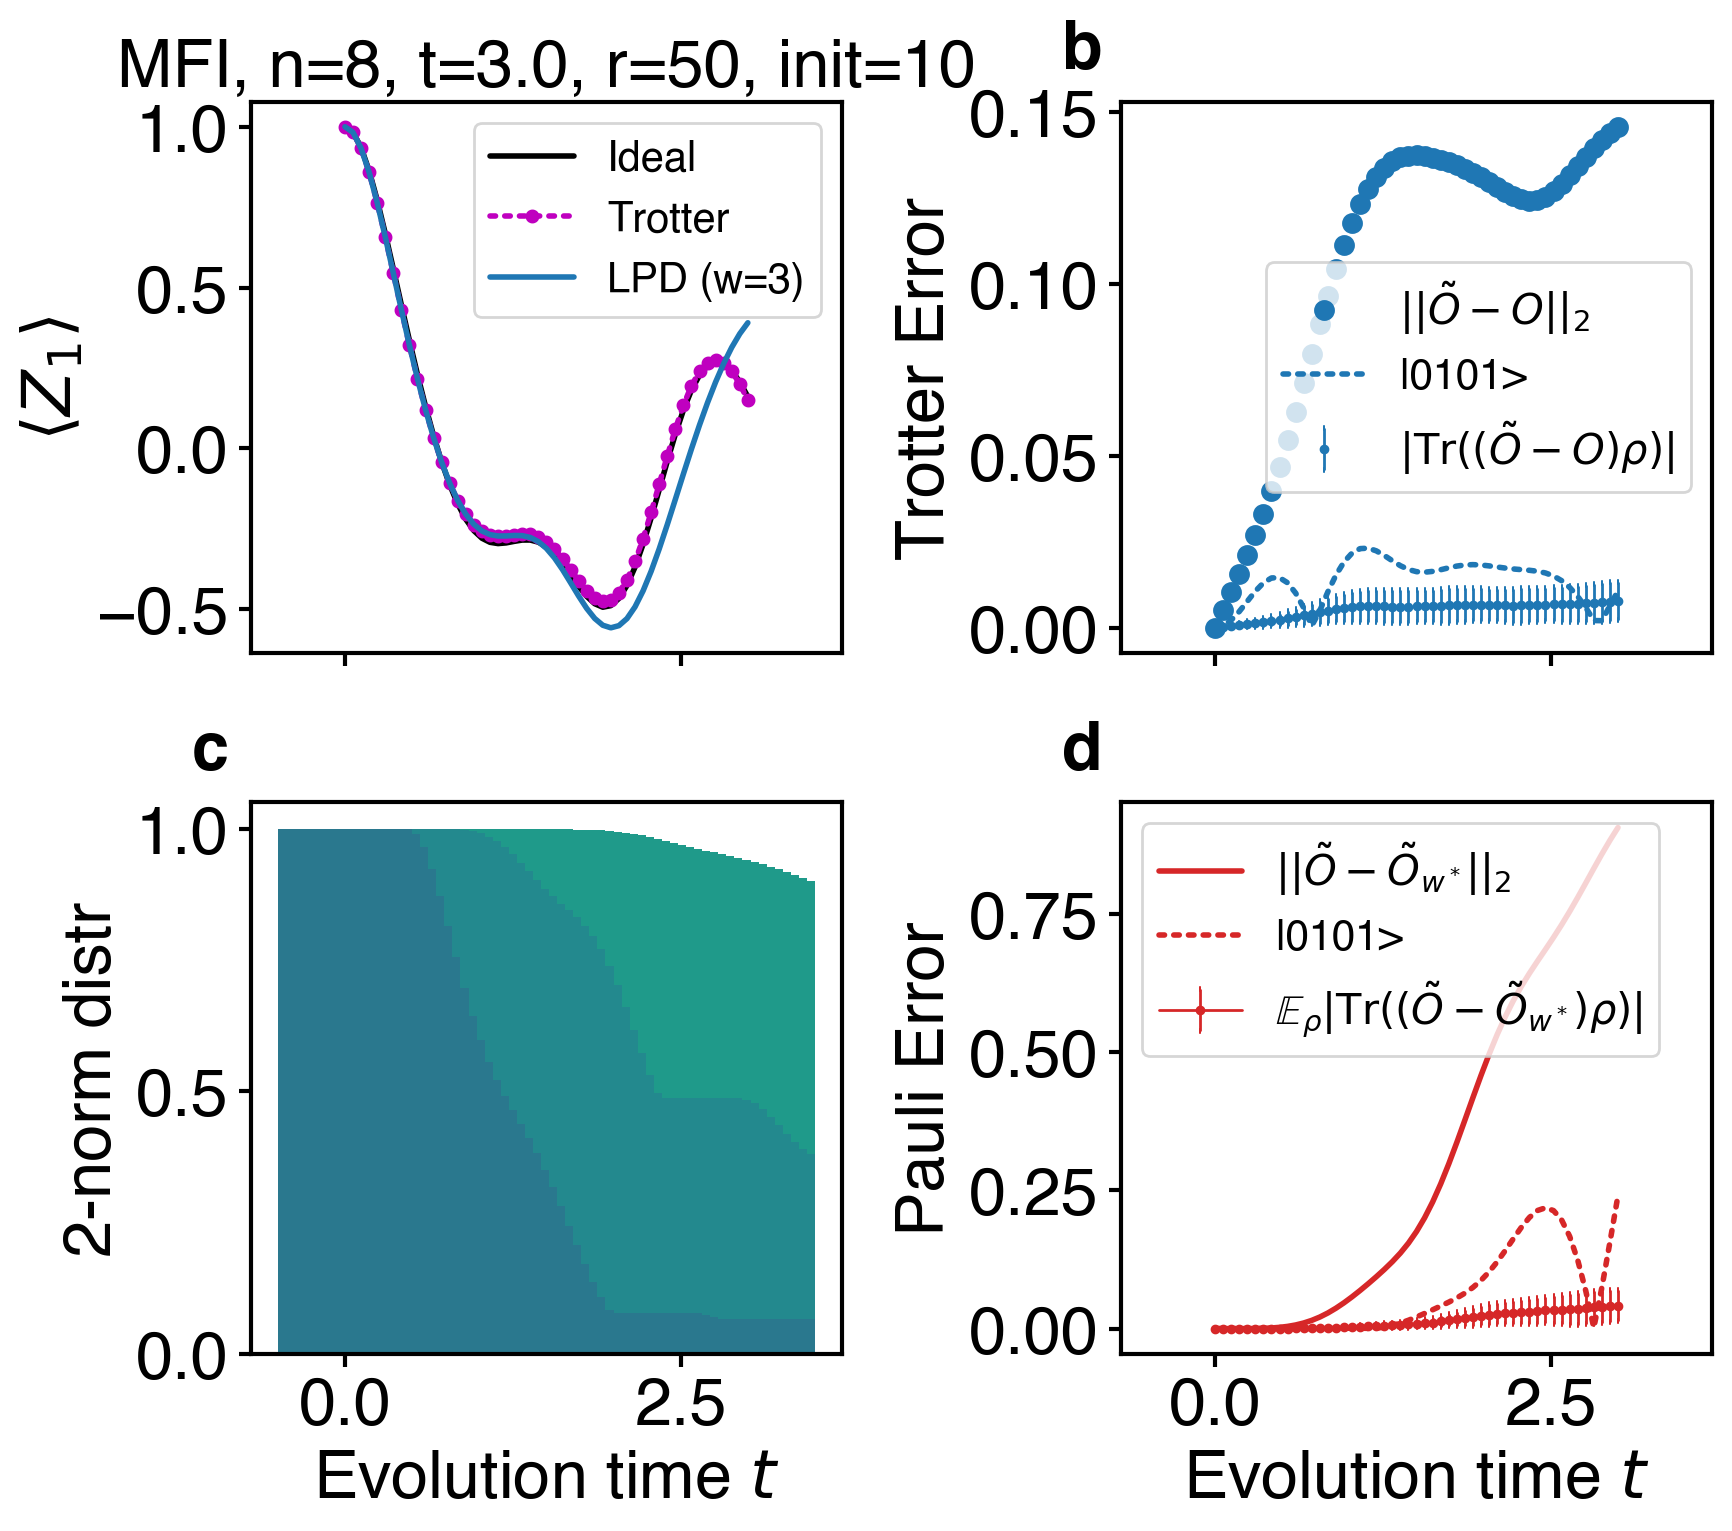

In [115]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8)) # , layout='constrained'
axes[0,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
axes[0,0].plot(t_list, res.real, label=f'LPD (w={w_thres})')
axes[1,0].set_xlabel(rf'Evolution time $t$'); 
axes[0,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0,0].legend(loc='upper right', fontsize='small')
axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

axes[1,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[1,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{E}_{\rho}|\text{Tr}((\tilde{O}-\tilde{O}_{ w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1,1].plot(t_list, abs(trott_expvals-res), ':', label=f'|0101>', c='tab:red')
axes[1,1].set_ylabel(rf'Pauli Error'); axes[1,1].legend(loc='upper left', fontsize='small')
axes[1,1].set_xlabel(rf'Evolution time $t$'); 
axes[0,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:blue')
axes[0,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.', label=r'$|\text{Tr}((\tilde{O}-O)\rho)|$', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[0,1].plot(t_list, abs(np.array(trott_expvals)-np.array(ideal_expvals)), ':', label=f'|0101>', c='tab:blue')
axes[0,1].set_ylabel(rf'Trotter Error'); axes[0,1].legend(loc='center right', fontsize='small')

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(trott_expvals))]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = axes[1,0].bar(t_list, norm2_distr, 1, color=colors[w-1], label=f'w<={w}')
axes[1,0].set_ylabel('2-norm distr') # axes[0,1].legend(loc='upper right')

for ax, label in zip(axes.flatten(), ['', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}.pdf', bbox_inches='tight')

In [98]:
print(sim.observable.size(), log(sim.observable.size(), 4), np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs))
# sim.evo_obs
evolved_ob = sim.observable.to_sparse_pauli_op(n)
print(len(evolved_ob.simplify()), log(len(evolved_ob.simplify()), 4), np.linalg.norm(evolved_ob.coeffs)/np.linalg.norm(obs.coeffs), np.linalg.norm(evolved_ob.simplify().coeffs)/np.linalg.norm(obs.coeffs))

1248 5.142701109431124 0.9485082471454982
1088 5.0437314206251695 0.9485082471454983 0.9485082471454973


In [121]:
sim.observable.bits[0]

array([0, 1], dtype=uint64)

In [134]:
print(len(sim.observable.bits))
temp = [0, 0]
for i, item in enumerate(sim.observable.bits):
    for rest in sim.observable.bits[i+1:]:
        if np.array_equal(item, rest):
            print(item)
# find the duplicate items in sim.observable.bits
# has_duplicates = len(sim.observable.bits) != len({tuple(row) for row in sim.observable.bits})
# print(has_duplicates)
unique_rows, counts = np.unique(sim.observable.bits, axis=0, return_counts=True)

print("Unique rows:\n", unique_rows, len(unique_rows))
print("Counts:", counts)
print("Duplicate rows exist?", np.any(counts > 1))

1248
Unique rows:
 [[  0   1]
 [  0   2]
 [  0   3]
 ...
 [224 160]
 [224 192]
 [224 224]] 1248
Counts: [1 1 1 ... 1 1 1]
Duplicate rows exist? False


In [137]:
print(len([tuple(row) for row in sim.observable.bits]))
len(set([tuple(row) for row in sim.observable.bits]))

1248


1248

In [83]:
print(sim.observable.weights)
sim.observable.to_sparse_pauli_op(n)

[1 1 2 ... 3 3 3]


SparsePauliOp(['IIIIIIIX', 'IIIIIIXI', 'IIIIIIXX', 'IIIIIXII', 'IIIIIXIX', 'IIIIIXXI', 'IIIIIXXX', 'IIIIXIII', 'IIIIXIIX', 'IIIIXIXI', 'IIIIXIXX', 'IIIIXXII', 'IIIIXXIX', 'IIIIXXXI', 'IIIXIIII', 'IIIXIIIX', 'IIIXIIXI', 'IIIXIIXX', 'IIIXIXII', 'IIIXIXXI', 'IIIXXIII', 'IIIXXIIX', 'IIIXXIXI', 'IIIXXXII', 'IIXIIIII', 'IIXIIIIX', 'IIXIIIXI', 'IIXIIIXX', 'IIXIIXII', 'IIXIIXXI', 'IIXIXIII', 'IIXIXXII', 'IIXXIIII', 'IIXXIIIX', 'IIXXIIXI', 'IIXXIXII', 'IIXXXIII', 'IXIIIIII', 'IXIIIIIX', 'IXIIIIXI', 'IXIIIIXX', 'IXIIIXII', 'IXIIIXXI', 'IXIIXIII', 'IXIIXXII', 'IXIXIIII', 'IXIXXIII', 'IXXIIIII', 'IXXIIIIX', 'IXXIIIXI', 'IXXIIXII', 'IXXIXIII', 'IXXXIIII', 'XIIIIIII', 'XIIIIIIX', 'XIIIIIXI', 'XIIIIIXX', 'XIIIIXII', 'XIIIIXXI', 'XIIIXIII', 'XIIIXXII', 'XIIXIIII', 'XIIXXIII', 'XIXIIIII', 'XIXXIIII', 'XXIIIIII', 'XXIIIIIX', 'XXIIIIXI', 'XXIIIXII', 'XXIIXIII', 'XXIXIIII', 'XXXIIIII', 'IIIIIIIZ', 'IIIIIIIY', 'IIIIIIXZ', 'IIIIIIXY', 'IIIIIXIZ', 'IIIIIXIY', 'IIIIIXXZ', 'IIIIIXXY', 'IIIIXIIZ', 'IIIIXIIY', '

In [13]:
gx = 1.4
gz = 0.9045
nsites = 8
# nsites = 21
hx = SparsePauliOp.from_sparse_list([('X', [i], gx) for i in range(nsites)], num_qubits=nsites)
hz = SparsePauliOp.from_sparse_list([('Z', [i], gz) for i in range(nsites)], num_qubits=nsites)
hzz = SparsePauliOp.from_sparse_list([('ZZ', [i, i+1], 1.0) for i in range(nsites-1)], num_qubits=nsites)
print(hx._pauli_list)
print(hx._coeffs)
hi = [hx[0] + hz[0] + hzz[0]/2] + [hx[i] + hz[i] + hzz[i-1] / 2 + hzz[i] / 2 for i in range(1, nsites-1)] + [hx[nsites-1] + hz[nsites-1] + hzz[nsites-2]/2]
# print(hi)

def exp_val_func(observable):
    return [observable.overlap(PauliRepresentation.from_sparse_pauli_op(h)) for h in hi]

['IIIIIIIX', 'IIIIIIXI', 'IIIIIXII', 'IIIIXIII', 'IIIXIIII', 'IIXIIIII',
 'IXIIIIII', 'XIIIIIII']
[1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j]


In [14]:
dt = 0.01
nsteps = 4
threshold = 0.001
# nsteps = 200
# threshold = 0.00001
ops = dt*(hz + hzz + hx)
obs = hi[(nsites-1)//2]
print('ops:', ops)
print('obs:', obs)

sim = Simulation.from_pauli_list(obs, ops, threshold=threshold, nprocs=4)
r = sim.run_dynamics(nsteps, process=exp_val_func, process_every = 10)
r = np.array(r)
r = r / r[0].sum()
print(sim.observable.size(), np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs))


ops: SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII', 'ZZIIIIII', 'IIIIIIIX', 'IIIIIIXI', 'IIIIIXII', 'IIIIXIII', 'IIIXIIII', 'IIXIIIII', 'IXIIIIII', 'XIIIIIII'],
              coeffs=[0.009045+0.j, 0.009045+0.j, 0.009045+0.j, 0.009045+0.j, 0.009045+0.j,
 0.009045+0.j, 0.009045+0.j, 0.009045+0.j, 0.01    +0.j, 0.01    +0.j,
 0.01    +0.j, 0.01    +0.j, 0.01    +0.j, 0.01    +0.j, 0.01    +0.j,
 0.014   +0.j, 0.014   +0.j, 0.014   +0.j, 0.014   +0.j, 0.014   +0.j,
 0.014   +0.j, 0.014   +0.j, 0.014   +0.j])
obs: SparsePauliOp(['IIIIXIII', 'IIIIZIII', 'IIIIZZII', 'IIIZZIII'],
              coeffs=[1.4   +0.j, 0.9045+0.j, 0.5   +0.j, 0.5   +0.j])


100%|██████████| 4/4 [00:00<00:00, 129.89it/s]

10 0.9999978313840797


In [6]:
tp = PauliRepresentation.from_pauli_list(PauliList('XYZII'))
tsop = tp.to_sparse_pauli_op(5)
print(tsop, tp.nq)
# print(PauliList('XYZII')._z)
print('weight of single Pauli: ', tp.weights)
# print(tp)
# Create some Pauli operators
paulis = PauliList(['XYZII', 'IIIII', 'ZZZZZ', 'XXIII'])
# Convert to PauliRepresentation
pauli_rep = PauliRepresentation.from_pauli_list(paulis, [1,2,3,4])
print('number of Paulis:', pauli_rep.n_pauli)
print('bit rep: ', pauli_rep.bits)
print('weights: ', pauli_rep.weights)
print('phases: ', pauli_rep.phase)
print('coeffs: ', pauli_rep.coeffs)
print('2 norm: ', pauli_rep.p2norm())
pauli_rep_w = decompose_by_weight_pauli_rep(pauli_rep)
# print(pauli_rep_w[0])
for key in pauli_rep_w:
    item = pauli_rep_w[key]
    print(item.p2norm()**2, item.weights, item.size())


# Get weights efficiently
weights = pauli_rep.weight()
print(f"Weights: {weights}")  # Output: Weights: [3 0 5 2]
print('anticommutes: ', pauli_rep.anticommutes(tp))
print('indices (anti):', np.where(pauli_rep.anticommutes(tp))[0])

SparsePauliOp(['XYZII'],
              coeffs=[1.+0.j]) 1
weight of single Pauli:  [3]
number of Paulis: 4
bit rep:  [[12 24]
 [ 0  0]
 [31  0]
 [ 0 24]]
weights:  [3 0 5 2]
phases:  [1 0 0 0]
coeffs:  [1, 2, 3, 4]
2 norm:  3.8729833462074166
1.9999999999999996 [0] 1
7.999999999999998 [2] 1
0.4999999999999999 [3] 1
4.499999999999999 [5] 1
Weights: [3 0 5 2]
anticommutes:  [False False False  True]
indices (anti): [3]


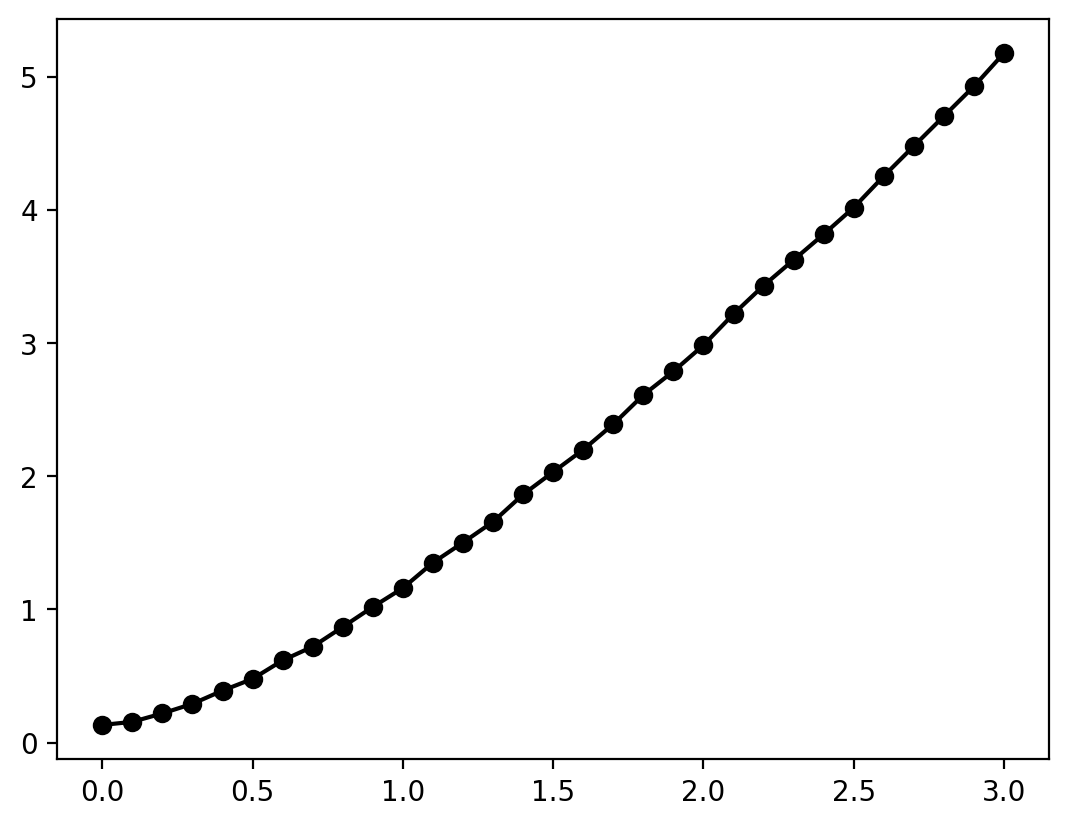

In [ ]:
def msd(a):
    j = np.arange(1,len(a)+1)
    return np.sum(a*j**2) - np.sum(a*j)**2
d2 = [msd(ri) for ri in r]

fig, ax = plt.subplots(1, 1)
ax.plot(np.arange(len(d2))/10, abs(np.array(d2)), '-ok')
# ax.set_ylim(0, 7)
plt.show()